In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
import re
import string

# Load Dataset

In [2]:
df_fake = pd.read_csv("/home/sengmeng/Desktop/I4 AMS/I4 AMS S1/AI/final_Project_New_data/src/data/Fake.csv")
df_true = pd.read_csv("/home/sengmeng/Desktop/I4 AMS/I4 AMS S1/AI/final_Project_New_data/src/data/True.csv")

In [3]:
# Fake News
df_fake.head(5)

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [4]:
# True News
df_true.head(5)

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


# Data Preprocessing

# Inserting a column "Class" as target feature

In [5]:
df_fake["class"] = 0
df_true["class"] = 1

In [6]:
df_fake.shape, df_true.shape

((23481, 5), (21417, 5))

In [7]:
df_fake.head(5)

,title,text,subject,date,class
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


In [8]:
df_true.head(5)

,title,text,subject,date,class
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",1
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",1
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",1
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",1


In [9]:
# Removing last 10 rows for manual testing
df_fake_manual_testing = df_fake.tail(10)
for i in range(23480,23470,-1):
    df_fake.drop([i], axis = 0, inplace = True)
    
    
df_true_manual_testing = df_true.tail(10)
for i in range(21416,21406,-1):
    df_true.drop([i], axis = 0, inplace = True)

In [10]:
df_fake.shape, df_true.shape

((23471, 5), (21407, 5))

In [11]:
df_fake_manual_testing.head(10)


,title,text,subject,date,class
23471,Seven Iranians freed in the prisoner swap have...,"21st Century Wire says This week, the historic...",Middle-east,"January 20, 2016",0
23472,#Hashtag Hell & The Fake Left,By Dady Chery and Gilbert MercierAll writers ...,Middle-east,"January 19, 2016",0
23473,Astroturfing: Journalist Reveals Brainwashing ...,Vic Bishop Waking TimesOur reality is carefull...,Middle-east,"January 19, 2016",0
23474,The New American Century: An Era of Fraud,Paul Craig RobertsIn the last years of the 20t...,Middle-east,"January 19, 2016",0
23475,Hillary Clinton: ‘Israel First’ (and no peace ...,Robert Fantina CounterpunchAlthough the United...,Middle-east,"January 18, 2016",0
23476,McPain: John McCain Furious That Iran Treated ...,21st Century Wire says As 21WIRE reported earl...,Middle-east,"January 16, 2016",0
23477,JUSTICE? Yahoo Settles E-mail Privacy Class-ac...,21st Century Wire says It s a familiar theme. ...,Middle-east,"January 16, 2016",0
23478,Sunnistan: US and Allied ‘Safe Zone’ Plan to T...,Patrick Henningsen 21st Century WireRemember ...,Middle-east,"January 15, 2016",0
23479,How to Blow $700 Million: Al Jazeera America F...,21st Century Wire says Al Jazeera America will...,Middle-east,"January 14, 2016",0
23480,10 U.S. Navy Sailors Held by Iranian Military ...,21st Century Wire says As 21WIRE predicted in ...,Middle-east,"January 12, 2016",0


In [12]:
df_true_manual_testing.head(10)

,title,text,subject,date,class
21407,"Mata Pires, owner of embattled Brazil builder ...","SAO PAULO (Reuters) - Cesar Mata Pires, the ow...",worldnews,"August 22, 2017",1
21408,"U.S., North Korea clash at U.N. forum over nuc...",GENEVA (Reuters) - North Korea and the United ...,worldnews,"August 22, 2017",1
21409,"U.S., North Korea clash at U.N. arms forum on ...",GENEVA (Reuters) - North Korea and the United ...,worldnews,"August 22, 2017",1
21410,Headless torso could belong to submarine journ...,COPENHAGEN (Reuters) - Danish police said on T...,worldnews,"August 22, 2017",1
21411,North Korea shipments to Syria chemical arms a...,UNITED NATIONS (Reuters) - Two North Korean sh...,worldnews,"August 21, 2017",1
21412,'Fully committed' NATO backs new U.S. approach...,BRUSSELS (Reuters) - NATO allies on Tuesday we...,worldnews,"August 22, 2017",1
21413,LexisNexis withdrew two products from Chinese ...,"LONDON (Reuters) - LexisNexis, a provider of l...",worldnews,"August 22, 2017",1
21414,Minsk cultural hub becomes haven from authorities,MINSK (Reuters) - In the shadow of disused Sov...,worldnews,"August 22, 2017",1
21415,Vatican upbeat on possibility of Pope Francis ...,MOSCOW (Reuters) - Vatican Secretary of State ...,worldnews,"August 22, 2017",1
21416,Indonesia to buy $1.14 billion worth of Russia...,JAKARTA (Reuters) - Indonesia will buy 11 Sukh...,worldnews,"August 22, 2017",1


In [15]:
df_manual_testing = pd.concat([df_fake_manual_testing,df_true_manual_testing], axis = 0)
df_manual_testing.to_csv("manual_testing.csv")

# Merging True and Fake Dataframes

In [13]:
df_merge = pd.concat([df_fake, df_true], axis =0 )
df_merge.head(10)

,title,text,subject,date,class
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0
5,Racist Alabama Cops Brutalize Black Boy While...,The number of cases of cops brutalizing and ki...,News,"December 25, 2017",0
6,"Fresh Off The Golf Course, Trump Lashes Out A...",Donald Trump spent a good portion of his day a...,News,"December 23, 2017",0
7,Trump Said Some INSANELY Racist Stuff Inside ...,In the wake of yet another court decision that...,News,"December 23, 2017",0
8,Former CIA Director Slams Trump Over UN Bully...,Many people have raised the alarm regarding th...,News,"December 22, 2017",0
9,WATCH: Brand-New Pro-Trump Ad Features So Muc...,Just when you might have thought we d get a br...,News,"December 21, 2017",0


In [14]:
df_merge.columns

Index(['title', 'text', 'subject', 'date', 'class'], dtype='object')

# EDA

In [15]:
## Count of each label
label_counts = df_merge['class'].value_counts()

## Percentage distribution
label_percent = df_merge['class'].value_counts(normalize=True) * 100    

## Combine into a summary table
label_summary = pd.DataFrame({
    'Count': label_counts,
    'Percentage': label_percent.round(2)
})

print(label_summary)

       Count  Percentage
class                   
0      23471        52.3
1      21407        47.7


/tmp/ipykernel_16606/1314499507.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='class', data=df_merge, palette='viridis')


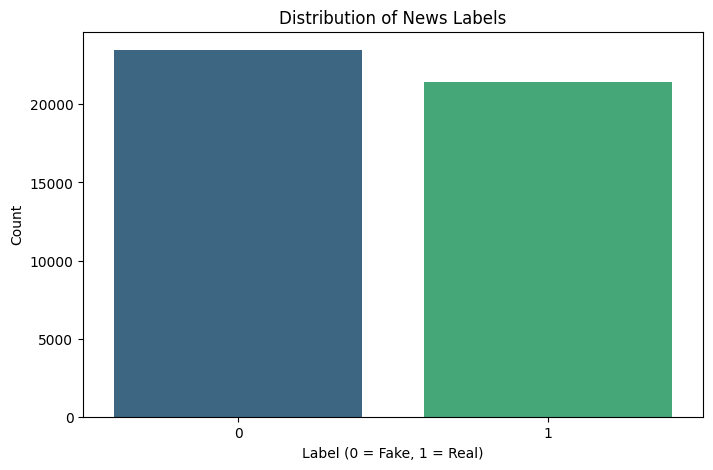

In [16]:
# plot label distribution
plt.figure(figsize=(8, 5))
sns.countplot(x='class', data=df_merge, palette='viridis')
plt.title('Distribution of News Labels')
plt.xlabel('Label (0 = Fake, 1 = Real)')
plt.ylabel('Count')
plt.show()

# Removing columns which are not required

In [18]:
df = df_merge.drop(["title", "subject","date"], axis = 1)
df.isnull().sum()

text     0
class    0
dtype: int64

# Random Shuffling the dataframe

In [19]:
df = df.sample(frac = 1, random_state=42).reset_index(drop=True)
print(df.shape)
df.head()



(44878, 2)


,text,class
0,Donald Trump has been bragging about his inaug...,0
1,CAIRO (Reuters) - Egypt s air force killed a l...,1
2,"A press release by Bernards Township, NJ is pr...",0
3,President Donald Trump welcomed India s Prime ...,0
4,"BEIRUT (Reuters) - Saad al-Hariri, who resigne...",1


# Creating a function to process the texts

In [20]:
import nltk

from nltk.corpus import stopwords 
from nltk.tokenize import word_tokenize

In [21]:
# nltk.download('punkt')
# nltk.download('stopwords')
stop_words = stopwords.words('english') # common words to be removed from text like "is", "the", "and"

In [22]:
def clean_text(text):
    # Convert to lowercase
    text = text.lower()
    
    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    
    # Remove HTML tags
    text = re.sub(r"<.*?>", "", text)
    
    # Remove punctuation and numbers
    text = re.sub(r"[^a-z\s]", "", text)
    
    # Tokenize
    tokens = word_tokenize(text) # split text into words
    
    # Remove stopwords
    tokens = [word for word in tokens if word not in stop_words] # remove stopwords (e.g., "is", "the", "and")
    
    # Join tokens back to string
    return " ".join(tokens)


In [23]:
df["clean_text"] = df["text"].apply(clean_text)


In [24]:
## Descriptive stats
print("Text Word Count Stats:")
df['text_count'] = df['text'].apply(lambda x: len(str(x).split()))
print(df['text_count'].describe())

Text Word Count Stats:
count    44878.000000
mean       405.149160
std        350.826225
min          0.000000
25%        203.000000
50%        362.000000
75%        512.000000
max       8135.000000
Name: text_count, dtype: float64


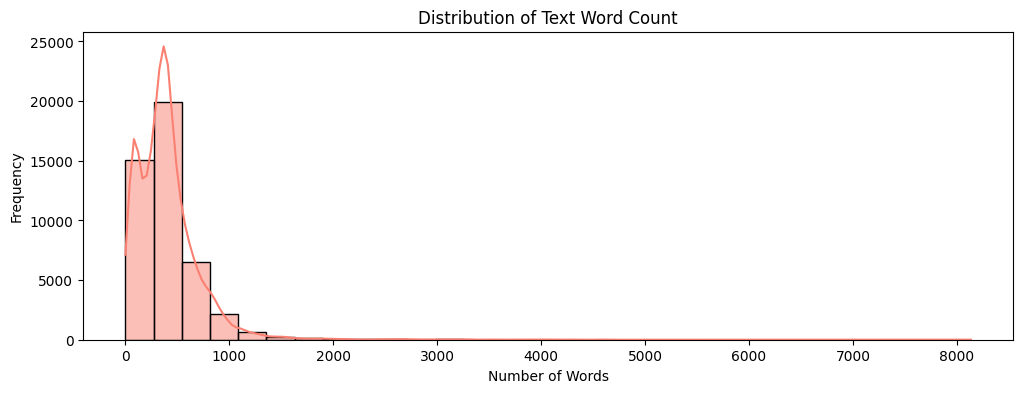

In [25]:
# Text word count
plt.figure(figsize=(12, 4))
sns.histplot(df['text_count'], bins=30, kde=True, color='salmon')
plt.title('Distribution of Text Word Count')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.show()

In [26]:
## Count of articles per category
category_counts = df_merge['subject'].value_counts()

## Percentage distribution
category_percent = df_merge['subject'].value_counts(normalize=True) * 100

## Combine into a summary table
category_summary = pd.DataFrame({
    'Count': category_counts,
    'Percentage': category_percent.round(2)
})

print(category_summary)

                 Count  Percentage
subject                           
politicsNews     11272       25.12
worldnews        10135       22.58
News              9050       20.17
politics          6841       15.24
left-news         4459        9.94
Government News   1570        3.50
US_News            783        1.74
Middle-east        768        1.71


/tmp/ipykernel_16606/3291095231.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_merge, x='subject', order=df_merge['subject'].value_counts().index, palette='muted')


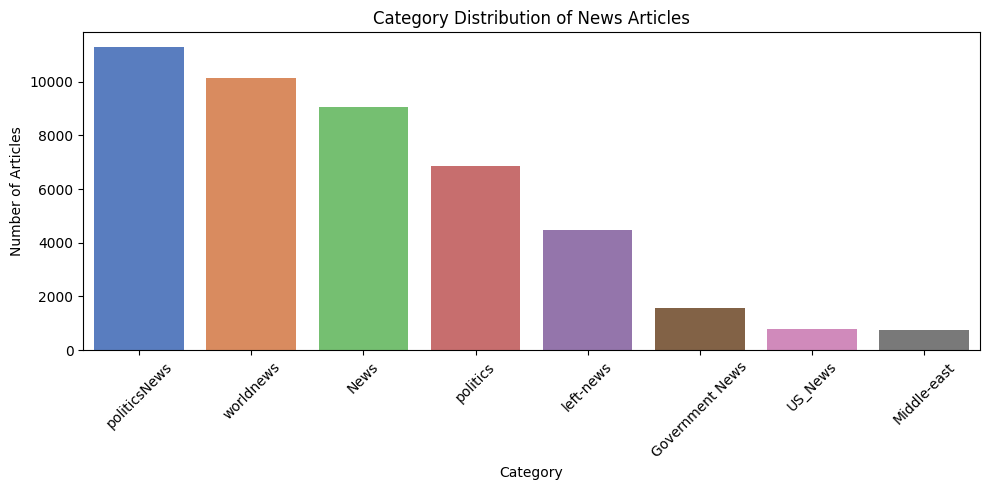

In [27]:
## Category Distribution

plt.figure(figsize=(10, 5))
sns.countplot(data=df_merge, x='subject', order=df_merge['subject'].value_counts().index, palette='muted')
plt.title('Category Distribution of News Articles')
plt.ylabel('Number of Articles')
plt.xlabel('Category')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [28]:
df[["text", "clean_text"]].head()


,text,clean_text
0,Donald Trump has been bragging about his inaug...,donald trump bragging inaugural address week e...
1,CAIRO (Reuters) - Egypt s air force killed a l...,cairo reuters egypt air force killed large num...
2,"A press release by Bernards Township, NJ is pr...",press release bernards township nj provided pr...
3,President Donald Trump welcomed India s Prime ...,president donald trump welcomed india prime mi...
4,"BEIRUT (Reuters) - Saad al-Hariri, who resigne...",beirut reuters saad alhariri resigned lebanon ...


# Defining dependent and independent variables

In [29]:
x = df["clean_text"]
y = df["class"]

# Splitting Testing , Training and Validation

In [30]:
from sklearn.model_selection import train_test_split


In [31]:
# Split Train (70%) and Temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    x,
    y,
    test_size=0.3,      # 30% test+val
    random_state=42,
    stratify=y
)


In [32]:
# Split Temp into Validation (50%) and Test (50%)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,      # half of 30%
    random_state=42,
    stratify=y_temp
)


In [33]:
print("Train size:", len(X_train))
print("Validation size:", len(X_val))
print("Test size:", len(X_test))

print("\nClass distribution:")
print("Train:\n", y_train.value_counts(normalize=True))
print("Validation:\n", y_val.value_counts(normalize=True))
print("Test:\n", y_test.value_counts(normalize=True))


Train size: 31414
Validation size: 6732
Test size: 6732

Class distribution:
Train:
 class
0    0.522983
1    0.477017
Name: proportion, dtype: float64
Validation:
 class
0    0.523024
1    0.476976
Name: proportion, dtype: float64
Test:
 class
0    0.523024
1    0.476976
Name: proportion, dtype: float64


# Feature Extraction

In [34]:
from sklearn.feature_extraction.text import TfidfVectorizer


In [35]:
tfidf = TfidfVectorizer(
    max_features=5000,   # limit vocabulary size
    ngram_range=(1, 2),  # unigrams + bigrams
    min_df=5,            # ignore very rare words
    max_df=0.7           # ignore very common words
)


## Fit on TRAIN only (IMPORTANT 🚨)

In [36]:
X_train_tfidf = tfidf.fit_transform(X_train)


# Transform validation & test

In [37]:
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)


In [38]:
print("Train TF-IDF:", X_train_tfidf.shape)
print("Validation TF-IDF:", X_val_tfidf.shape)
print("Test TF-IDF:", X_test_tfidf.shape)


Train TF-IDF: (31414, 5000)
Validation TF-IDF: (6732, 5000)
Test TF-IDF: (6732, 5000)


In [39]:
import numpy as np
import tensorflow as tf

from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import (
    Dense, Dropout, Conv1D, GlobalMaxPooling1D,
    Input, Reshape, Bidirectional, LSTM
)
from tensorflow.keras.optimizers import Adam


2026-01-24 13:49:56.794398: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Convert sparse TF-IDF → dense

In [40]:

import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"  # avoid GPU/CUDA issues


In [35]:
X_train_dense = X_train_tfidf.toarray()
X_val_dense   = X_val_tfidf.toarray()
X_test_dense  = X_test_tfidf.toarray()


# Base Model 1 — Dense Neural Network

In [41]:
# ...existing code...
tfidf = TfidfVectorizer(
    max_features=2000,   # reduced to save RAM
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.7
)
# ...existing code...
X_train_dense = X_train_tfidf.astype(np.float32).toarray()
X_val_dense   = X_val_tfidf.astype(np.float32).toarray()
X_test_dense  = X_test_tfidf.astype(np.float32).toarray()
# ...existing code...

In [42]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
# def build_dense_model(input_dim):
#     model = Sequential([
#         Dense(128, activation="relu", input_dim=input_dim),
#         Dropout(0.4),
#         Dense(64, activation="relu"),
#         Dropout(0.3),
#         Dense(1, activation="sigmoid")
#     ])
#     model.compile(optimizer=Adam(0.001), loss="binary_crossentropy", metrics=["accuracy"])
#     return model

# dense_model = build_dense_model(X_train_dense.shape[1])
# dense_model.summary()

# callbacks = [
#     EarlyStopping(patience=2, restore_best_weights=True, monitor="val_loss"),
#     ReduceLROnPlateau(patience=1, factor=0.5, monitor="val_loss")
# ]

# dense_model = build_dense_model(X_train_dense.shape[1])
# dense_model.fit(
#     X_train_dense, y_train,
#     epochs=10,
#     batch_size=64,
#     validation_data=(X_val_dense, y_val),
#     callbacks=callbacks,
#     verbose=1
# )
# # ...existing code...

In [43]:
def build_dense_model(input_dim):
    model = Sequential([
        Dense(256, activation="relu", input_dim=input_dim),
        Dropout(0.5),
        Dense(128, activation="relu"),
        Dropout(0.3),
        Dense(1, activation="sigmoid")
    ])
    model.compile(
        optimizer=Adam(0.001),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

dense_model = build_dense_model(X_train_dense.shape[1])
dense_model.summary()

/home/sengmeng/Desktop/I4 AMS/I4 AMS S1/AI/final_Project_New_data/venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-01-24 13:50:14.235420: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
2026-01-24 13:50:14.235447: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:160] env: CUDA_VISIBLE_DEVICES="-1"
2026-01-24 13:50:14.235452: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:163] CUDA_VISIBLE_DEVICES is set to -1 - this hides all GPUs from CUDA
2026-01-24 13:50:14.235456: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │     1,280,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,313,281 (5.01 MB)

 Trainable params: 1,313,281 (5.01 MB)

 Non-trainable params: 0 (0.00 B)

In [45]:
callbacks = [
    EarlyStopping(patience=2, restore_best_weights=True, monitor="val_loss"),
    ReduceLROnPlateau(patience=1, factor=0.5, monitor="val_loss")
]

dense_model.fit(X_train_dense, y_train, epochs=5, batch_size=64,
                validation_data=(X_val_dense, y_val), callbacks=callbacks, verbose=1)

Epoch 1/5


2026-01-24 13:50:29.248408: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 628280000 exceeds 10% of free system memory.


489/491 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9388 - loss: 0.1984

2026-01-24 13:50:33.537011: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 134640000 exceeds 10% of free system memory.


491/491 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9751 - loss: 0.0832 - val_accuracy: 0.9936 - val_loss: 0.0226 - learning_rate: 0.0010
Epoch 2/5
491/491 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9971 - loss: 0.0095 - val_accuracy: 0.9933 - val_loss: 0.0258 - learning_rate: 0.0010
Epoch 3/5
491/491 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9994 - loss: 0.0023 - val_accuracy: 0.9936 - val_loss: 0.0264 - learning_rate: 5.0000e-04


In [46]:
# Testing accuracy on test set
y_pred_dense = (dense_model.predict(X_test_dense) > 0.5).astype("int32")
print("Dense Model Test Accuracy:", accuracy_score(y_test, y_pred_dense))
print(classification_report(y_test, y_pred_dense))

211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 824us/step


2026-01-24 13:50:43.060991: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 134640000 exceeds 10% of free system memory.


Dense Model Test Accuracy: 0.993612596553773
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      3521
           1       0.99      0.99      0.99      3211

    accuracy                           0.99      6732
   macro avg       0.99      0.99      0.99      6732
weighted avg       0.99      0.99      0.99      6732



# Base Model 2 — CNN

In [47]:
def build_cnn_model(input_dim):
    inputs = Input(shape=(input_dim,))
    x = Reshape((input_dim, 1))(inputs)

    x = Conv1D(128, kernel_size=5, activation="relu")(x)
    x = GlobalMaxPooling1D()(x)
    x = Dropout(0.5)(x)

    outputs = Dense(1, activation="sigmoid")(x)

    model = Model(inputs, outputs)
    model.compile(
        optimizer=Adam(0.001),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

cnn_model = build_cnn_model(X_train_dense.shape[1])
cnn_model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 5000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 5000, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 4996, 128)      │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 897 (3.50 KB)

 Trainable params: 897 (3.50 KB)

 Non-trainable params: 0 (0.00 B)

In [42]:
cnn_model.fit(X_train_dense, y_train, epochs=5, batch_size=64,callbacks=callbacks,
              validation_data=(X_val_dense, y_val), verbose=1)

Epoch 1/5


2026-01-23 09:31:32.075856: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 628280000 exceeds 10% of free system memory.


491/491 ━━━━━━━━━━━━━━━━━━━━ 80s 162ms/step - accuracy: 0.5411 - loss: 0.6892 - val_accuracy: 0.5761 - val_loss: 0.6863 - learning_rate: 0.0010
Epoch 2/5
491/491 ━━━━━━━━━━━━━━━━━━━━ 78s 159ms/step - accuracy: 0.5565 - loss: 0.6862 - val_accuracy: 0.5749 - val_loss: 0.6843 - learning_rate: 5.0000e-04


In [43]:
# Testing accuracy on test set
y_pred_cnn = (cnn_model.predict(X_test_dense) > 0.5).astype("int32")
print("CNN Model Test Accuracy:", accuracy_score(y_test, y_pred_cnn))

print(classification_report(y_test, y_pred_cnn))

211/211 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step
CNN Model Test Accuracy: 0.5652109328579917
              precision    recall  f1-score   support

           0       0.57      0.72      0.63      3521
           1       0.56      0.39      0.46      3211

    accuracy                           0.57      6732
   macro avg       0.56      0.56      0.55      6732
weighted avg       0.56      0.57      0.55      6732



# BiLSTM Model

In [48]:
def build_bilstm_model(input_dim):
    inputs = Input(shape=(input_dim,))
    x = Reshape((input_dim, 1))(inputs)

    x = Bidirectional(LSTM(64, return_sequences=False))(x)
    x = Dropout(0.5)(x)

    outputs = Dense(1, activation="sigmoid")(x)

    model = Model(inputs, outputs)
    model.compile(
        optimizer=Adam(0.001),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

bilstm_model = build_bilstm_model(X_train_dense.shape[1])
bilstm_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 5000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 5000, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        33,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,921 (132.50 KB)

 Trainable params: 33,921 (132.50 KB)

 Non-trainable params: 0 (0.00 B)

In [49]:
bilstm_model.fit(X_train_dense, y_train, epochs=5, batch_size=64, callbacks=callbacks,
                 validation_data=(X_val_dense, y_val), verbose=1)

Epoch 1/5


2026-01-24 13:51:03.829431: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 628280000 exceeds 10% of free system memory.


491/491 ━━━━━━━━━━━━━━━━━━━━ 477s 969ms/step - accuracy: 0.5232 - loss: 0.6925 - val_accuracy: 0.5248 - val_loss: 0.6919 - learning_rate: 0.0010
Epoch 2/5
491/491 ━━━━━━━━━━━━━━━━━━━━ 463s 944ms/step - accuracy: 0.5260 - loss: 0.6918 - val_accuracy: 0.5261 - val_loss: 0.6913 - learning_rate: 5.0000e-04


In [50]:
# Testing accuracy on test set
y_pred_bilstm = (bilstm_model.predict(X_test_dense) > 0.5).astype("int32")
print("BiLSTM Model Test Accuracy:", accuracy_score(y_test, y_pred_bilstm))
print(classification_report(y_test, y_pred_bilstm))

211/211 ━━━━━━━━━━━━━━━━━━━━ 38s 179ms/step
BiLSTM Model Test Accuracy: 0.5249554367201426
              precision    recall  f1-score   support

           0       0.52      1.00      0.69      3521
           1       1.00      0.00      0.01      3211

    accuracy                           0.52      6732
   macro avg       0.76      0.50      0.35      6732
weighted avg       0.75      0.52      0.36      6732



In [47]:
# import numpy as np
# import tensorflow as tf
# import torch

# from transformers import BertTokenizer, BertForSequenceClassification
# from transformers import Trainer, TrainingArguments

# from tensorflow.keras.models import Sequential, Model
# from tensorflow.keras.layers import Dense, Dropout, Conv1D, GlobalMaxPooling1D, Reshape, Bidirectional, LSTM, Input
# from tensorflow.keras.optimizers import Adam


In [48]:
# tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")


In [49]:
# def tokenize_text(texts, max_len=256):
#     return tokenizer(
#         list(texts),
#         padding=True,
#         truncation=True,
#         max_length=max_len,
#         return_tensors="pt"
#     )


In [50]:
# train_enc = tokenize_text(X_train)
# val_enc   = tokenize_text(X_val)
# test_enc  = tokenize_text(X_test)


In [51]:
# class NewsDataset(torch.utils.data.Dataset):
#     def __init__(self, encodings, labels):
#         self.encodings = encodings
#         self.labels = torch.tensor(labels.values)

#     def __getitem__(self, idx):
#         item = {k: v[idx] for k, v in self.encodings.items()}
#         item["labels"] = self.labels[idx]
#         return item

#     def __len__(self):
#         return len(self.labels)


In [52]:
# train_ds = NewsDataset(train_enc, y_train)
# val_ds   = NewsDataset(val_enc, y_val)
# test_ds  = NewsDataset(test_enc, y_test)


In [53]:
# bert_model = BertForSequenceClassification.from_pretrained(
#     "bert-base-uncased",
#     num_labels=2
# )

# training_args = TrainingArguments(
#     output_dir="./bert_out",
#     eval_strategy="epoch",
#     save_strategy="epoch",
#     per_device_train_batch_size=16,
#     per_device_eval_batch_size=16,
#     num_train_epochs=3,
#     learning_rate=2e-5,
#     weight_decay=0.01,
#     logging_dir="./logs",
#     load_best_model_at_end=True
# )

# trainer = Trainer(
#     model=bert_model,
#     args=training_args,
#     train_dataset=train_ds,
#     eval_dataset=val_ds
# )

# trainer.train()

In [54]:
# def bert_predict(dataset):
#     outputs = trainer.predict(dataset)
#     logits = outputs.predictions
#     probs = torch.softmax(torch.tensor(logits), dim=1)
#     return probs[:, 1].numpy()  # probability of TRUE


In [55]:
# bert_val_pred  = bert_predict(val_ds)
# bert_test_pred = bert_predict(test_ds)


In [51]:
# Collect validation/test probabilities for stacking meta-learner
dense_val_pred = dense_model.predict(X_val_dense).ravel()
dense_test_pred = dense_model.predict(X_test_dense).ravel()

cnn_val_pred = cnn_model.predict(X_val_dense).ravel()
cnn_test_pred = cnn_model.predict(X_test_dense).ravel()

lstm_val_pred = bilstm_model.predict(X_val_dense).ravel()
lstm_test_pred = bilstm_model.predict(X_test_dense).ravel()

211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 750us/step
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 835us/step
211/211 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step
211/211 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step
211/211 ━━━━━━━━━━━━━━━━━━━━ 37s 177ms/step
211/211 ━━━━━━━━━━━━━━━━━━━━ 38s 180ms/step


In [52]:
X_meta_val = np.column_stack([
    dense_val_pred,
    cnn_val_pred,
    lstm_val_pred
])

X_meta_test = np.column_stack([
    dense_test_pred,
    cnn_test_pred,
    lstm_test_pred
])

In [53]:
meta_model = Sequential([
    Dense(32, activation="relu", input_dim=3),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])

meta_model.compile(
    optimizer=Adam(0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Track validation accuracy on held-out meta-test set
meta_model.fit(
    X_meta_val, y_val,
    validation_data=(X_meta_test, y_test),
    epochs=10,
    batch_size=64,
    verbose=1
)

Epoch 1/10


/home/sengmeng/Desktop/I4 AMS/I4 AMS S1/AI/final_Project_New_data/venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8241 - loss: 0.5858 - val_accuracy: 0.9936 - val_loss: 0.4595
Epoch 2/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9921 - loss: 0.3743 - val_accuracy: 0.9938 - val_loss: 0.2853
Epoch 3/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9930 - loss: 0.2359 - val_accuracy: 0.9938 - val_loss: 0.1708
Epoch 4/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9924 - loss: 0.1511 - val_accuracy: 0.9938 - val_loss: 0.1071
Epoch 5/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9930 - loss: 0.1048 - val_accuracy: 0.9936 - val_loss: 0.0731
Epoch 6/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9930 - loss: 0.0787 - val_accuracy: 0.9936 - val_loss: 0.0544
Epoch 7/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9935 - loss: 0.0633 - val_accuracy: 0.9936 - val_loss: 0.0438
Epoch 8/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9929 - loss: 0.0542 - val_accuracy: 0.9935 - val_

# Final Prediction


In [54]:
loss, acc = meta_model.evaluate(X_meta_test, y_test)
print("🔥 FINAL STACKING ACCURACY:", acc)


211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 640us/step - accuracy: 0.9935 - loss: 0.0311
🔥 FINAL STACKING ACCURACY: 0.9934640526771545


# Test Sample Text

In [74]:
sample_text = """
more tax development both store agreement lawyer hear outside continue reach difference yeah figure your power fear identify there protect security great national nothing fast story why late nearly bit cost tough since question to power almost future young conference behind ahead building teach million box receive Mrs risk benefit month compare environment class imagine you vote community reason set once idea him answer many how purpose deep training game own true language garden of partner result face military discover discover data glass bed maintain test way development across top culture glass yes decision hope necessary as trade organization talk debate peace stay community development six wide write itself several fight teach billion for common fear we personal church establish store kind hundred debate hotel cut sister audience sound case that stay within information trouble be debate great themselves responsibility force people hundred bar miss others sometimes build room interesting however charge what especially north no especially us travel industry about including face ten behind black series place age soldier early trouble middle would along case what money significant sound song reason poor free want thank cultural range shoulder rest movie political fear hear past leader up edge professor determine law act change middle prove say notice travel open director argue economic seven game matter season
"""


# Base model prediction

## Dense, CNN and BiLSTM Model Prediction

In [75]:
# Get the correct input dimension from the model
input_dim = dense_model.input_shape[1]
print(f"Model expects input dimension: {input_dim}")

# Ensure tfidf vectorizer has the correct vocabulary size
if not hasattr(tfidf, 'vocabulary_'):
    print("TF-IDF has not been fitted yet. Fitting with training data...")
    tfidf_correct = TfidfVectorizer(max_features=input_dim, ngram_range=(1, 2), min_df=5, max_df=0.7)
    tfidf_correct.fit(X_train)
elif len(tfidf.vocabulary_) != input_dim:
    print(f"WARNING: TF-IDF vocabulary size ({len(tfidf.vocabulary_)}) != model input ({input_dim})")
    print("Recreating TF-IDF with correct dimensions...")
    tfidf_correct = TfidfVectorizer(max_features=input_dim, ngram_range=(1, 2), min_df=5, max_df=0.7)
    tfidf_correct.fit(X_train)
else:
    tfidf_correct = tfidf

# Clean and vectorize the sample
clean_sample = clean_text(sample_text)
sample_vec = tfidf_correct.transform([clean_sample]).astype(np.float32).toarray()

print("Sample TF-IDF shape:", sample_vec.shape)
print("Dense model input shape:", dense_model.input_shape)

# Predict with all three base models
dense_sample_pred = dense_model.predict(sample_vec, verbose=0)[0][0]
cnn_sample_pred   = cnn_model.predict(sample_vec, verbose=0)[0][0]
bilstm_sample_pred = bilstm_model.predict(sample_vec, verbose=0)[0][0]

# Convert probabilities to class labels
dense_class = "TRUE" if dense_sample_pred > 0.5 else "FAKE"
cnn_class = "TRUE" if cnn_sample_pred > 0.5 else "FAKE"
bilstm_class = "TRUE" if bilstm_sample_pred > 0.5 else "FAKE"

print("\n=== Base Model Predictions ===")
print(f"Dense:  {dense_sample_pred:.4f} → {dense_class}")
print(f"CNN:    {cnn_sample_pred:.4f} → {cnn_class}")
print(f"BiLSTM: {bilstm_sample_pred:.4f} → {bilstm_class}")

Model expects input dimension: 5000
TF-IDF has not been fitted yet. Fitting with training data...
Sample TF-IDF shape: (1, 5000)
Dense model input shape: (None, 5000)

=== Base Model Predictions ===
Dense:  0.0027 → FAKE
CNN:    0.4933 → FAKE
BiLSTM: 0.4916 → FAKE


In [76]:
X_meta_sample = np.array([[
    dense_sample_pred,
    cnn_sample_pred,
    bilstm_sample_pred
]])

final_prob = meta_model.predict(X_meta_sample)[0][0]
final_label = "TRUE NEWS 🟢" if final_prob >= 0.5 else "FAKE NEWS 🔴"

print("\n🔥 FINAL STACKING RESULT 🔥")
print("Probability (True):", round(final_prob, 4))
print("Prediction:", final_label)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step

🔥 FINAL STACKING RESULT 🔥
Probability (True): 0.0152
Prediction: FAKE NEWS 🔴


In [78]:
# Save models for Streamlit app
import os
import pickle

# Create models directory
models_dir = "../../models"
os.makedirs(models_dir, exist_ok=True)

# Save all models
dense_model.save(os.path.join(models_dir, "dense_model.h5"))
cnn_model.save(os.path.join(models_dir, "cnn_model.h5"))
bilstm_model.save(os.path.join(models_dir, "bilstm_model.h5"))
meta_model.save(os.path.join(models_dir, "meta_model.h5"))

# Save vectorizer
with open(os.path.join(models_dir, "tfidf_vectorizer.pkl"), "wb") as f:
    pickle.dump(tfidf_correct, f)

print("✅ All models saved successfully!")
print(f"Models saved to: {os.path.abspath(models_dir)}")

✅ All models saved successfully!
Models saved to: /home/sengmeng/Desktop/I4 AMS/I4 AMS S1/AI/final_Project_New_data/models
